In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max.columns', None)
pd.set_option('display.max.rows', None)
sns.set(style='darkgrid', font_scale=1.2)


In [2]:
# 2. Load Data
# (Assumes the CSV is in the current directory)
data = pd.read_csv('Dry_Beans_Multiclass_Classification.csv')
print('Data loaded. Shape:', data.shape)
data.head()

Data loaded. Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
# 3. Check for Missing Values
missing = data.isnull().sum()
print('Missing values per column:')
print(missing)
if missing.sum() == 0:
    print('No missing values found.')
else:
    print('Missing values found! Handle before proceeding.')

Missing values per column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64
No missing values found.


In [4]:
# 4. Outlier Treatment (IQR Capping)
numeric_cols = data.select_dtypes(include=np.number).columns
data_capped = data.copy()
for col in numeric_cols:
    Q1 = data_capped[col].quantile(0.25)
    Q3 = data_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data_capped[col] = np.where(data_capped[col] < lower, lower, np.where(data_capped[col] > upper, upper, data_capped[col]))
print('Outlier capping complete.')
data_capped.head()

Outlier capping complete.


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.57412,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.57412,29172.0,191.272751,0.783968,0.984986,0.887034,0.941972,0.006979,0.003564,0.867978,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.57412,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,210.557999,182.516516,1.153638,0.57412,30724.0,195.467062,0.782681,0.979156,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.57412,30417.0,195.896503,0.773098,0.990893,0.984877,0.941972,0.006697,0.003665,0.867978,0.999166,SEKER


In [5]:
# 5. Feature Scaling & Label Encoding
X = data_capped.drop('Class', axis=1)
y = data_capped['Class']

# Scale numeric features
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('Features scaled and target encoded.')
print('Classes:', label_encoder.classes_)

Features scaled and target encoded.
Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [6]:
# 6. Skewness Check & PowerTransformer
skewness = pd.Series(X_scaled[numeric_cols].skew())
skewed_cols = skewness[skewness.abs() > 0.75].index.tolist()
if skewed_cols:
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    X_scaled[skewed_cols] = pt.fit_transform(X_scaled[skewed_cols])
    print('PowerTransformer applied to:', skewed_cols)
else:
    print('No highly skewed columns found.')

PowerTransformer applied to: ['Area', 'Perimeter', 'MajorAxisLength', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'ShapeFactor4']


In [7]:
# 7. Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print('Train/Test split complete.')
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])

Train/Test split complete.
Train size: 10888 | Test size: 2723


Test Accuracy: 0.927653323540213
Test Precision: 0.9409399743234659
Test Recall: 0.9369065444929561
Test F1 Score: 0.9388401179619414

Train Accuracy: 0.9694158706833211
Train Precision: 0.9754042088040266
Train Recall: 0.9730468747936373
Train F1 Score: 0.9741958740849553

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.93      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.95      0.96      0.95       406
        SIRA       0.87      0.87      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



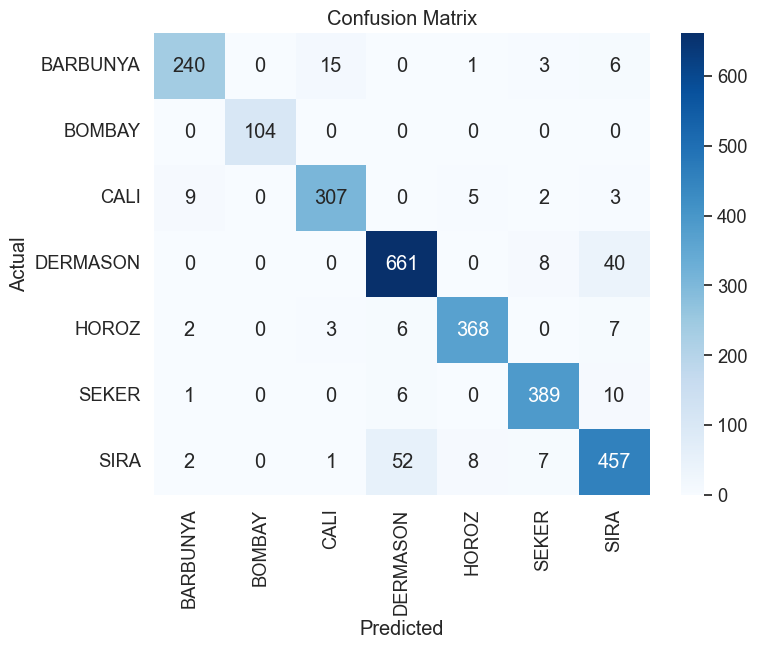

In [8]:
# 8. Train & Evaluate Tuned CatBoost Model
catboost_params = {
    'learning_rate': 0.05,
    'l2_leaf_reg': 5,
    'iterations': 500,
    'depth': 10,
    'border_count': 128,
    'random_state': 42,
    'verbose': 0
}
model = CatBoostClassifier(**catboost_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average='macro')
test_recall = recall_score(y_test, y_pred, average='macro')
test_f1 = f1_score(y_test, y_pred, average='macro')

# train metrices
train_accuracy = accuracy_score(y_train, model.predict(X_train))
train_precision = precision_score(y_train, model.predict(X_train), average='macro')
train_recall = recall_score(y_train, model.predict(X_train), average='macro')
train_f1 = f1_score(y_train, model.predict(X_train), average='macro')

print('Test Accuracy:', test_accuracy)
print('Test Precision:', test_precision)
print('Test Recall:', test_recall)
print('Test F1 Score:', test_f1)

print('\nTrain Accuracy:', train_accuracy)
print('Train Precision:', train_precision)
print('Train Recall:', train_recall)
print('Train F1 Score:', train_f1)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
# Saving the trained model and scaler using joblib
import joblib
joblib.dump(model, 'catboost_dry_beans_model.pkl', compress=3)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']